### Let's start the homework now...

Something which comes at first glance is:
- Technical indicators: some of the technical features seem to contain values of the stock price after the date of the execution (these features contain information relevant to the performance, and will be a sign of data leakage). 

`'close_0', 'close_sp500_0', 'close_365', 'close_sp500_365'`
- Financial indicators: there is a risk that at the execution date some companies have already presented their financial statements, while others not...
- A company reports 4 times a year... forever (as long as it stays in the SP500). This means that in the train dataset, if we're predicting about NVIDIA Q1 2022 and the training dataset contains the revenues and prices of NVIDA as of Q4 2023... There an inherent data leakage in the training dataset. The samples are not independent as the answer of one sample (outperforming SP500) is available in another sample.
One possible solution to this problem could be making the samples annonymous? This could be removing the ticker, company name, absolute prices and absolute financial values. Instead, a company will be uniquely represented by relative performance of financials and technical indicators. Instead of global revenues, we should consider revenue growth... Instead of prices, we should consider price changes... Instead of debt, think of debt/equity... This will add a lot of variables (if we want to consider momemtum of price/financials over the years, there should be multiple features `revenue_growth_3m`, `revenue_growth_12m`... However, doing this wouldn't consider other intangible features in investing such as company values. Say for example the priceless value added of a good CEO. This tends to be reflected in the name of a company (COSTCO, Brookfield, Berkshire...). We can assume that the price and the financial health will reflect this intangible features.

But before doing anything... Let's try to check if the model is overfitting

In [68]:
import pandas as pd
import re
import numpy as np
import lightgbm as lgb
from plotnine import ggplot, geom_histogram, aes, geom_col, coord_flip,geom_bar,scale_x_discrete, geom_point, theme,element_text

In [69]:
data_set = pd.read_feather("data/financials_against_return.feather")

In [70]:
data_set.head()

,Ticker,date,AssetTurnover,CashFlowFromFinancialActivities,CashFlowFromInvestingActivities,CashFlowFromOperatingActivities,CashOnHand,ChangeInAccountsPayable,ChangeInAccountsReceivable,ChangeInAssetsLiabilities,...,EBIT_change_2_years,Revenue_change_1_years,Revenue_change_2_years,NetCashFlow_change_1_years,NetCashFlow_change_2_years,CurrentRatio_change_1_years,CurrentRatio_change_2_years,Market_cap__minus_365,Market_cap__minus_730,diff_ch_sp500
0,A,2005-01-31,0.1695,81.000,-57.000,137.000,2483.0000,5.000,44.000,-5.000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.304773
1,NDSN,2005-01-31,0.2248,-3.366,10.663,7.700,62.6220,NaN,NaN,-21.145,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.387846
2,HURC,2005-01-31,0.3782,0.483,-0.400,2.866,11.3030,0.156,0.854,-0.027,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.543440
3,NRT,2005-01-31,1.0517,NaN,NaN,NaN,4.9015,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.331322
4,HRL,2005-01-31,0.4880,-12.075,-113.077,83.476,145.2050,NaN,17.084,3.539,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.218482


The minimum number of tickers seems to be a good approach (although as per the exploration, it seems that all the quartes contain more than 1500 tickers)

In [71]:
minimum_number_of_tickers = 1500
df_quarter_lengths = data_set.groupby(["execution_date"]).size().reset_index().rename(columns = {0:"count"})
data_set = pd.merge(data_set, df_quarter_lengths, on = ["execution_date"])
data_set = data_set[data_set["count"]>=minimum_number_of_tickers]

In [72]:
data_set.shape

(170483, 145)

In [73]:
data_set["diff_ch_sp500"] = data_set["stock_change_div_365"] - data_set["sp500_change_365"]

data_set.loc[data_set["diff_ch_sp500"]>0,"target"] = 1
data_set.loc[data_set["diff_ch_sp500"]<0,"target"] = 0

data_set["target"].value_counts()

target
0.0    82437
1.0    73829
Name: count, dtype: int64

In [74]:
def get_weighted_performance_of_stocks(df,metric):
    df["norm_prob"] = 1/len(df)
    return np.sum(df["norm_prob"]*df[metric])

def get_top_tickers_per_prob(preds):
    if len(preds) == len(train_set):
        data_set = train_set.copy()
    elif len(preds) == len(test_set):
        data_set = test_set.copy()
    else:
        assert ("Not matching train/test")
    data_set["prob"] = preds
    data_set = data_set.sort_values(["prob"], ascending = False)
    data_set = data_set.head(top_n)
    return data_set

# main metric to evaluate: average diff_ch_sp500 of the top_n stocks
def top_wt_performance(preds, train_data):
    top_dataset = get_top_tickers_per_prob(preds)
    return "weighted-return", get_weighted_performance_of_stocks(top_dataset,"diff_ch_sp500"), True

In [75]:
def split_train_test_by_period(data_set, test_execution_date,include_nulls_in_test = False):
    # we train with everything happening at least one year before the test execution date
    train_set = data_set.loc[data_set["execution_date"] <= pd.to_datetime(test_execution_date) - pd.Timedelta(350, unit = "day")]
    # remove those rows where the target is null
    train_set = train_set[~pd.isna(train_set["diff_ch_sp500"])]
    execution_dates = train_set.sort_values("execution_date")["execution_date"].unique()
    # Pick only the last n_train_quarters
    if n_train_quarters!=None:
        train_set = train_set[train_set["execution_date"].isin(execution_dates[-n_train_quarters:])]
        
    # the test set are the rows happening in the execution date with the concrete frequency
    test_set = data_set.loc[(data_set["execution_date"] == test_execution_date)]
    if not include_nulls_in_test:
        test_set = test_set[~pd.isna(test_set["diff_ch_sp500"])]
    test_set = test_set.sort_values('date', ascending = False).drop_duplicates('Ticker', keep = 'first')
    
    return train_set, test_set

In [76]:
def get_columns_to_remove():
    columns_to_remove = [
                         "date",
                         "improve_sp500",
                         "Ticker",
                         "freq",
                         "set",
                         "close_sp500_365",
                         "close_365",
                         "stock_change_365",
                         "sp500_change_365",
                         "stock_change_div_365",
                         "stock_change_730",
                         "sp500_change_365",
                         "stock_change_div_730",
                         "diff_ch_sp500",
                         "diff_ch_avg_500",
                         "execution_date","target","index","quarter","std_730","count"]
        
    return columns_to_remove

In [77]:
import warnings
warnings.filterwarnings('ignore')


def train_model(train_set,test_set,n_estimators = 300):

    columns_to_remove = get_columns_to_remove()
    
    X_train = train_set.drop(columns = columns_to_remove, errors = "ignore")
    X_test = test_set.drop(columns = columns_to_remove, errors = "ignore")
    
    
    y_train = train_set["target"]
    y_test = test_set["target"]

    lgb_train = lgb.Dataset(X_train,y_train)
    lgb_test = lgb.Dataset(X_test, y_test, reference=lgb_train)
    
    eval_result = {}
    
 
    objective = 'binary'
    metric = 'binary_logloss' 
    params = {
             "random_state":1, 
             "verbosity": -1,
             "n_jobs":10, 
             "n_estimators":n_estimators,
             "objective": objective,
             "metric": metric}
    
    model = lgb.train(params = params,train_set = lgb_train,
                      valid_sets = [lgb_test,lgb_train],
                      feval = [top_wt_performance],
                      callbacks = [lgb.record_evaluation(eval_result = eval_result)])
    return model,eval_result,X_train,X_test

In [78]:
def run_model_for_execution_date(execution_date,all_results,all_predicted_tickers_list,all_models,n_estimators,include_nulls_in_test = False):
        global train_set
        global test_set
        # split the dataset between train and test
        train_set, test_set = split_train_test_by_period(data_set,execution_date,include_nulls_in_test = include_nulls_in_test)
        train_size, _ = train_set.shape
        test_size, _ = test_set.shape
        model = None
        X_train = None
        X_test = None
        
        # if both train and test are not empty
        if train_size > 0 and test_size>0:
            model, evals_result, X_train, X_test = train_model(train_set,
                                                              test_set,
                                                              n_estimators = n_estimators)
            
            test_set['prob'] = model.predict(X_test)
            predicted_tickers = test_set.sort_values('prob', ascending = False)
            predicted_tickers["execution_date"] = execution_date
            all_results[(execution_date)] = evals_result
            all_models[(execution_date)] = model
            all_predicted_tickers_list.append(predicted_tickers)
        return all_results,all_predicted_tickers_list,all_models,model,X_train,X_test

execution_dates = np.sort( data_set['execution_date'].unique() )


In [79]:


n_trees = 40
n_train_quarters = 36
top_n = 10

all_results = {}
all_predicted_tickers_list = []
all_models = {}


for execution_date in execution_dates:
    print(execution_date)
    all_results,all_predicted_tickers_list,all_models,model,X_train,X_test = run_model_for_execution_date(execution_date,all_results,all_predicted_tickers_list,all_models,n_trees,False)
all_predicted_tickers = pd.concat(all_predicted_tickers_list) 

2005-06-30T00:00:00.000000000
2005-09-30T00:00:00.000000000
2005-12-30T00:00:00.000000000
2006-03-31T00:00:00.000000000
2006-06-30T00:00:00.000000000
2006-09-30T00:00:00.000000000
2006-12-30T00:00:00.000000000
2007-03-31T00:00:00.000000000
2007-06-30T00:00:00.000000000
2007-09-30T00:00:00.000000000
2007-12-30T00:00:00.000000000
2008-03-31T00:00:00.000000000
2008-06-30T00:00:00.000000000
2008-09-30T00:00:00.000000000
2008-12-30T00:00:00.000000000
2009-03-31T00:00:00.000000000
2009-06-30T00:00:00.000000000
2009-09-30T00:00:00.000000000
2009-12-30T00:00:00.000000000
2010-03-31T00:00:00.000000000
2010-06-30T00:00:00.000000000
2010-09-30T00:00:00.000000000
2010-12-30T00:00:00.000000000
2011-03-31T00:00:00.000000000
2011-06-30T00:00:00.000000000
2011-09-30T00:00:00.000000000
2011-12-30T00:00:00.000000000
2012-03-31T00:00:00.000000000
2012-06-30T00:00:00.000000000
2012-09-30T00:00:00.000000000
2012-12-30T00:00:00.000000000
2013-03-31T00:00:00.000000000
2013-06-30T00:00:00.000000000
2013-09-30

In [21]:
def parse_results_into_df(set_):
    df = pd.DataFrame()
    for date in all_results:
        df_tmp = pd.DataFrame(all_results[(date)][set_])
        df_tmp["n_trees"] = list(range(len(df_tmp)))
        df_tmp["execution_date"] = date
        df= pd.concat([df,df_tmp])
    
    df["execution_date"] = df["execution_date"].astype(str)
    
    return df

In [22]:
test_results = parse_results_into_df("valid_0")
train_results = parse_results_into_df("training")

In [23]:
test_results_final_tree = test_results.sort_values(["execution_date","n_trees"]).drop_duplicates("execution_date",keep = "last")
train_results_final_tree = train_results.sort_values(["execution_date","n_trees"]).drop_duplicates("execution_date",keep = "last")

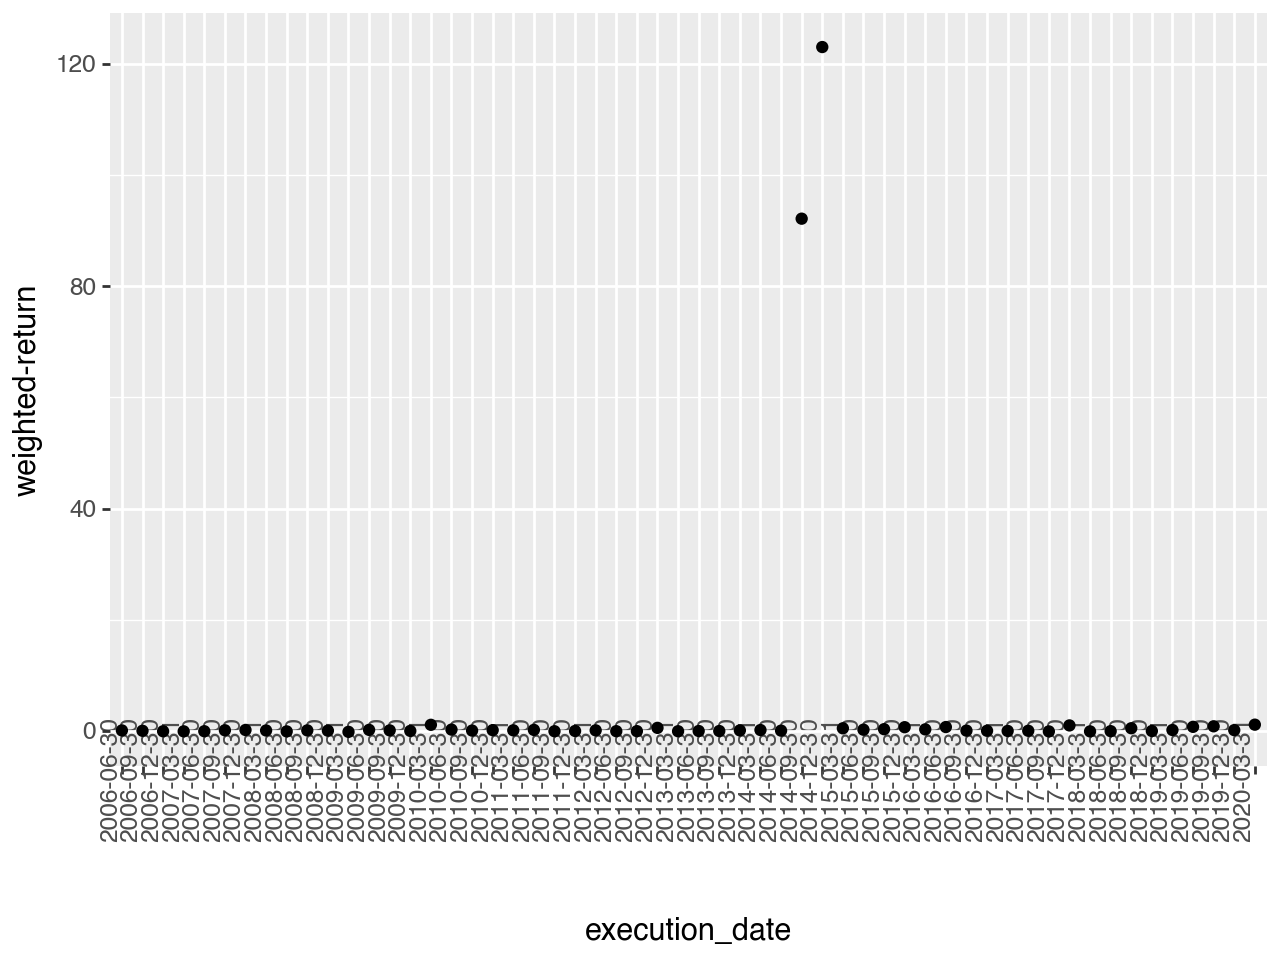

In [24]:
ggplot(test_results_final_tree) + geom_point(aes(x = "execution_date", y = "weighted-return")) + theme(axis_text_x = element_text(angle = 90, vjust = 0.5, hjust=1))

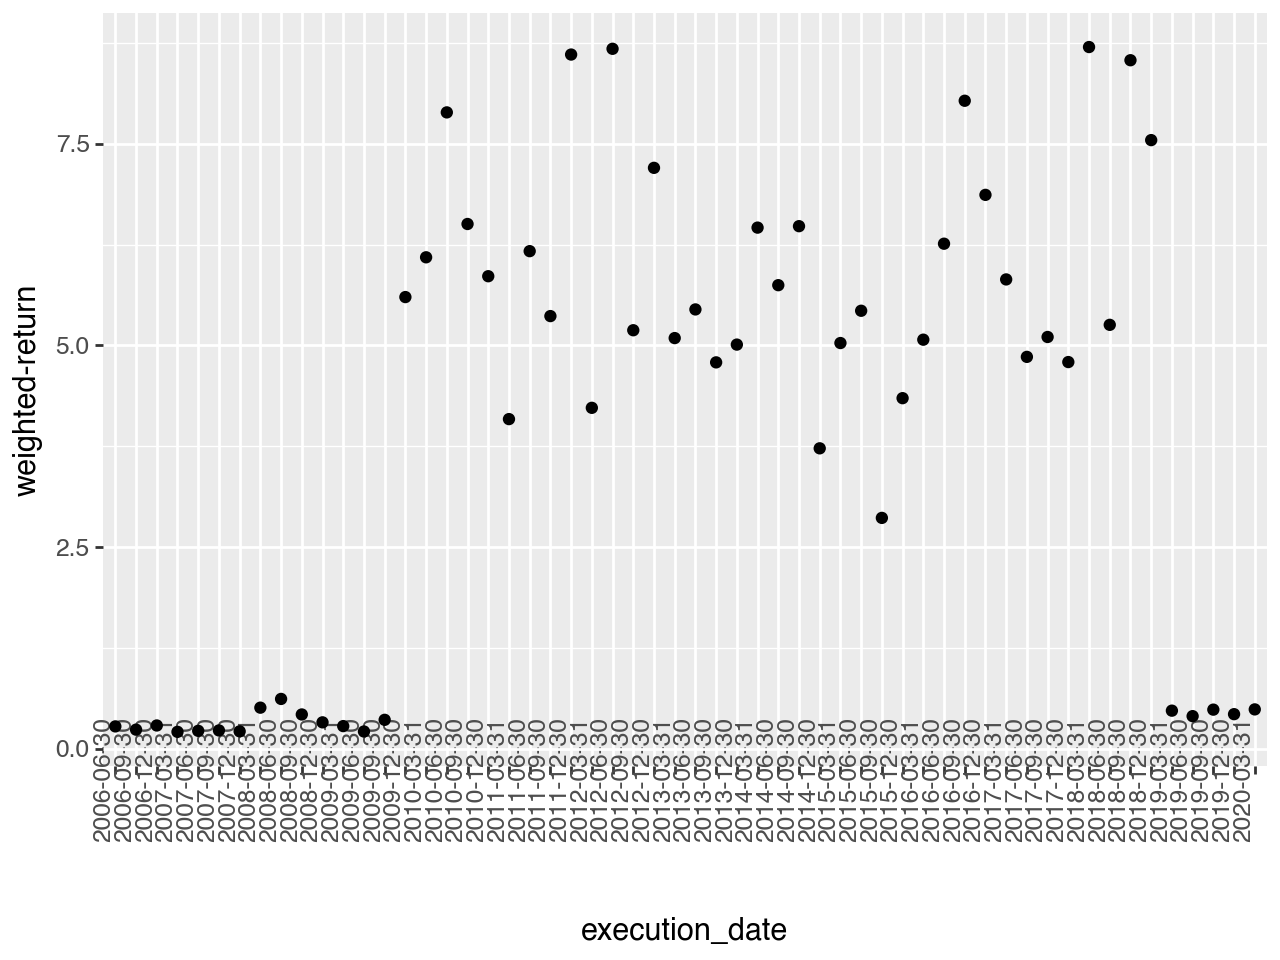

In [25]:
ggplot(train_results_final_tree) + geom_point(aes(x = "execution_date", y = "weighted-return")) + theme(axis_text_x = element_text(angle = 90, vjust = 0.5, hjust=1))

In [26]:
def draw_feature_importance(model,top = 15):
    fi = model.feature_importance()
    fn = model.feature_name()
    feature_importance = pd.DataFrame([{"feature":fn[i],"imp":fi[i]} for i in range(len(fi))])
    feature_importance = feature_importance.sort_values("imp",ascending = False).head(top)
    feature_importance = feature_importance.sort_values("imp",ascending = True)
    plot = ggplot(feature_importance,aes(x = "feature",y  = "imp")) + geom_col(fill = "lightblue") + coord_flip() +  scale_x_discrete(limits = feature_importance["feature"])
    return plot

In [27]:
import matplotlib.pyplot as plt
for model in all_models:
    plot = draw_feature_importance(all_models[model])
    plot.save(filename = "plots/it0/feature_importance_"+str(model)+".png",width = 10, height = 10)

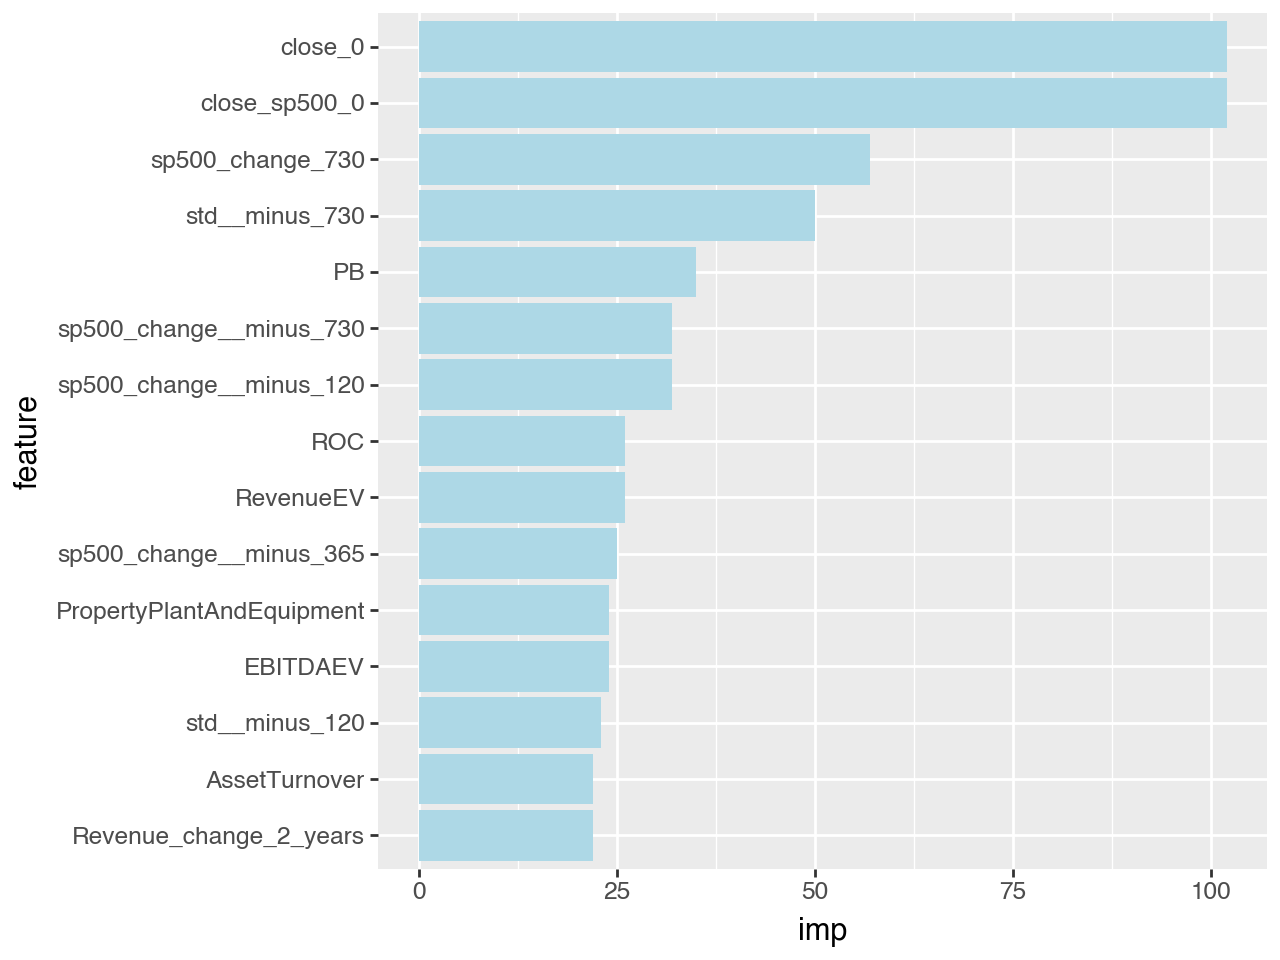

In [28]:
plot

As mentioned in the beginning, it seems like `close_0` and `close_sp500_0` are features which contain information (in the end, the represent relative information about the difference between the price of the stock and the price of the sp500, after making the decision...). Also, the change of the assets after the decision should be removed.

One thing to note here is that the SP500 does not seem to incorporate financial information... It's be also interesting to have past changes in financials for the SP500 to know which companies contain more momentum and can outperform... 

#TODO: check if there is a good way to incorporate sp500 financials (overall revenue growth for a certain period, market cap...)

In [29]:
[col for col in data_set.columns if "change" in col and col not in get_columns_to_remove() and "minus" not in col]

['sp500_change_730',
 'FreeCashFlowPerShare_change_1_years',
 'FreeCashFlowPerShare_change_2_years',
 'OperatingCashFlowPerShare_change_1_years',
 'OperatingCashFlowPerShare_change_2_years',
 'EBITDA_change_1_years',
 'EBITDA_change_2_years',
 'EBIT_change_1_years',
 'EBIT_change_2_years',
 'Revenue_change_1_years',
 'Revenue_change_2_years',
 'NetCashFlow_change_1_years',
 'NetCashFlow_change_2_years',
 'CurrentRatio_change_1_years',
 'CurrentRatio_change_2_years']

There seems to be a lot of variables which indicate financial performance after the date...

In [30]:
def get_columns_to_remove():
    columns_to_remove = [
                         "date",
                         "improve_sp500",
                         "Ticker",
                         "freq",
                         "set",
                         "close_sp500_365",
                         "close_365",
                         "stock_change_365",
                         "sp500_change_365",
                         "stock_change_div_365",
                         "stock_change_730",
                         "sp500_change_365",
                         "stock_change_div_730",
                         "diff_ch_sp500",
                         "diff_ch_avg_500",
                         "execution_date","target","index","quarter","std_730","count",
                         # additional removals
                         "close_0", 
                         "close_sp500_0", 
                         "sp500_change_730",
                         ]
        
    return columns_to_remove

In [31]:
n_trees = 40
n_train_quarters = 36
top_n = 10

all_results = {}
all_predicted_tickers_list = []
all_models = {}


for execution_date in execution_dates:
    print(execution_date)
    all_results,all_predicted_tickers_list,all_models,model,X_train,X_test = run_model_for_execution_date(execution_date,all_results,all_predicted_tickers_list,all_models,n_trees,False)
all_predicted_tickers = pd.concat(all_predicted_tickers_list) 

2005-06-30T00:00:00.000000000
2005-09-30T00:00:00.000000000
2005-12-30T00:00:00.000000000
2006-03-31T00:00:00.000000000
2006-06-30T00:00:00.000000000
2006-09-30T00:00:00.000000000
2006-12-30T00:00:00.000000000
2007-03-31T00:00:00.000000000
2007-06-30T00:00:00.000000000
2007-09-30T00:00:00.000000000
2007-12-30T00:00:00.000000000
2008-03-31T00:00:00.000000000
2008-06-30T00:00:00.000000000
2008-09-30T00:00:00.000000000
2008-12-30T00:00:00.000000000
2009-03-31T00:00:00.000000000
2009-06-30T00:00:00.000000000
2009-09-30T00:00:00.000000000
2009-12-30T00:00:00.000000000
2010-03-31T00:00:00.000000000
2010-06-30T00:00:00.000000000
2010-09-30T00:00:00.000000000
2010-12-30T00:00:00.000000000
2011-03-31T00:00:00.000000000
2011-06-30T00:00:00.000000000
2011-09-30T00:00:00.000000000
2011-12-30T00:00:00.000000000
2012-03-31T00:00:00.000000000
2012-06-30T00:00:00.000000000
2012-09-30T00:00:00.000000000
2012-12-30T00:00:00.000000000
2013-03-31T00:00:00.000000000
2013-06-30T00:00:00.000000000
2013-09-30

In [35]:
test_results = parse_results_into_df("valid_0")
train_results = parse_results_into_df("training")
test_results_final_tree = test_results.sort_values(["execution_date","n_trees"]).drop_duplicates("execution_date",keep = "last")
train_results_final_tree = train_results.sort_values(["execution_date","n_trees"]).drop_duplicates("execution_date",keep = "last")


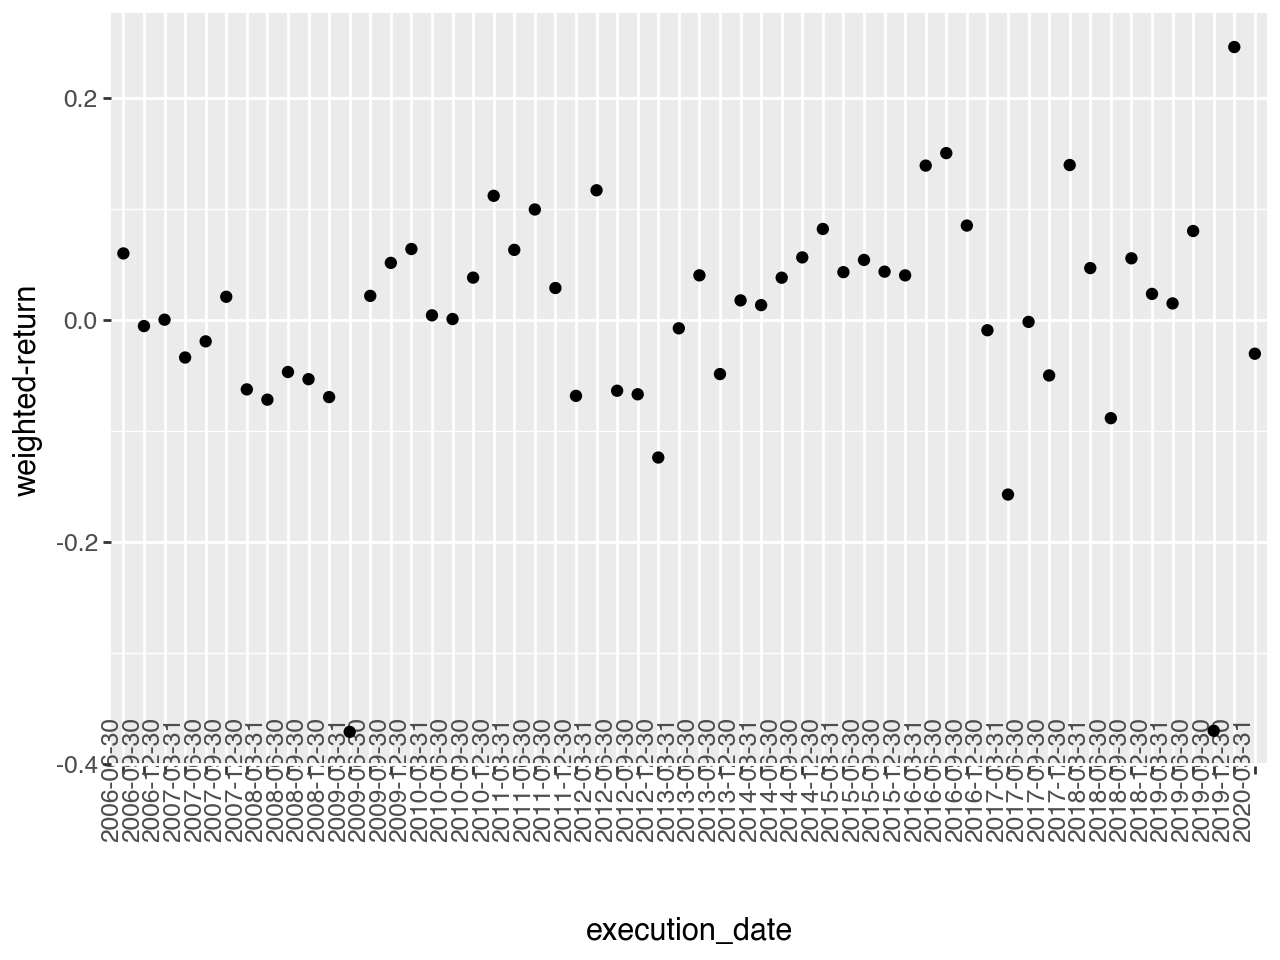

In [36]:
ggplot(test_results_final_tree) + geom_point(aes(x = "execution_date", y = "weighted-return")) + theme(axis_text_x = element_text(angle = 90, vjust = 0.5, hjust=1))

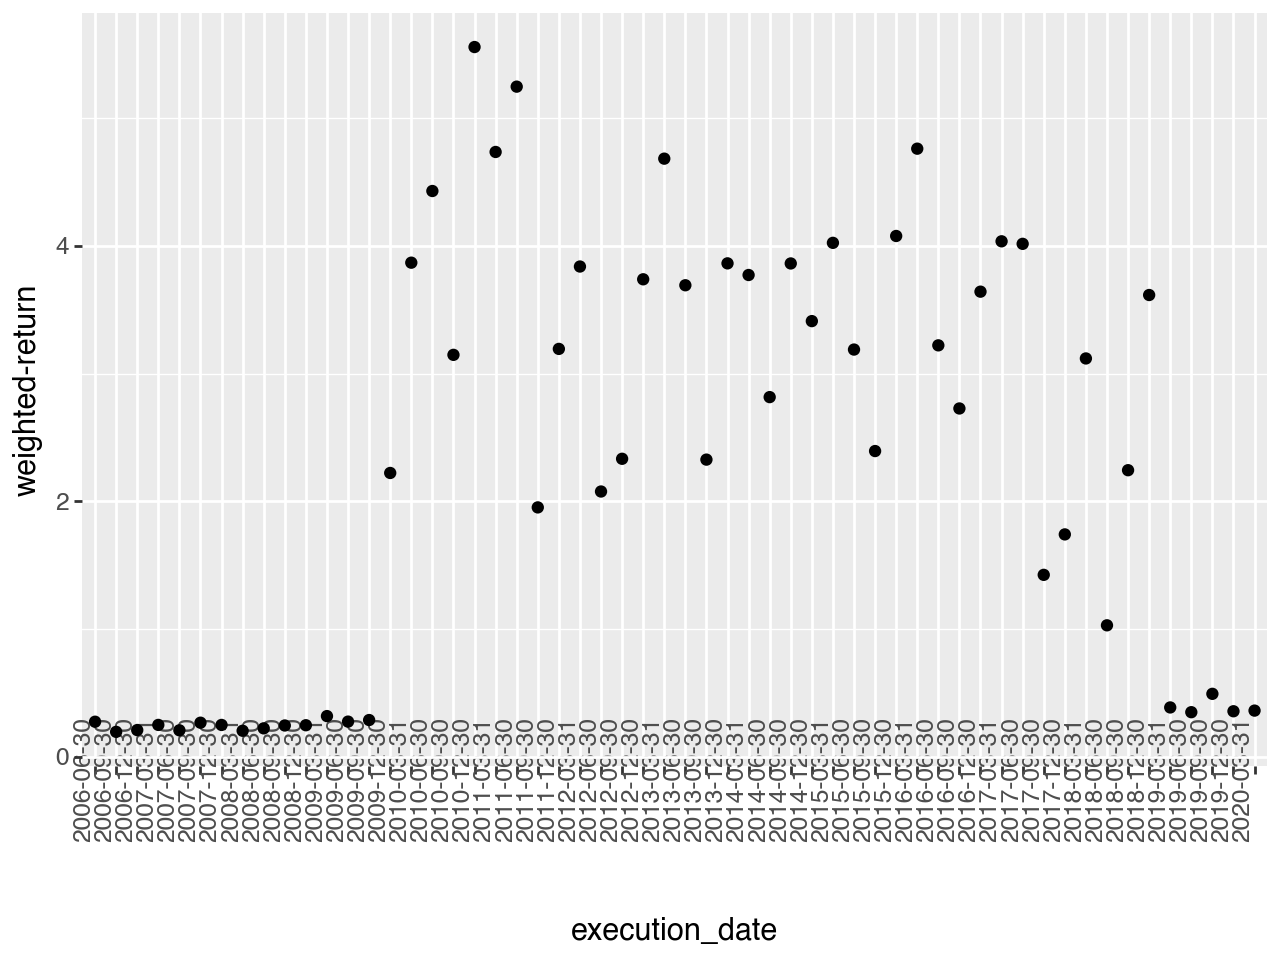

In [37]:
ggplot(train_results_final_tree) + geom_point(aes(x = "execution_date", y = "weighted-return")) + theme(axis_text_x = element_text(angle = 90, vjust = 0.5, hjust=1))

In [38]:
import matplotlib.pyplot as plt
for model in all_models:
    plot = draw_feature_importance(all_models[model])
    plot.save(filename = "plots/it1/feature_importance_"+str(model)+".png",width = 10, height = 10)

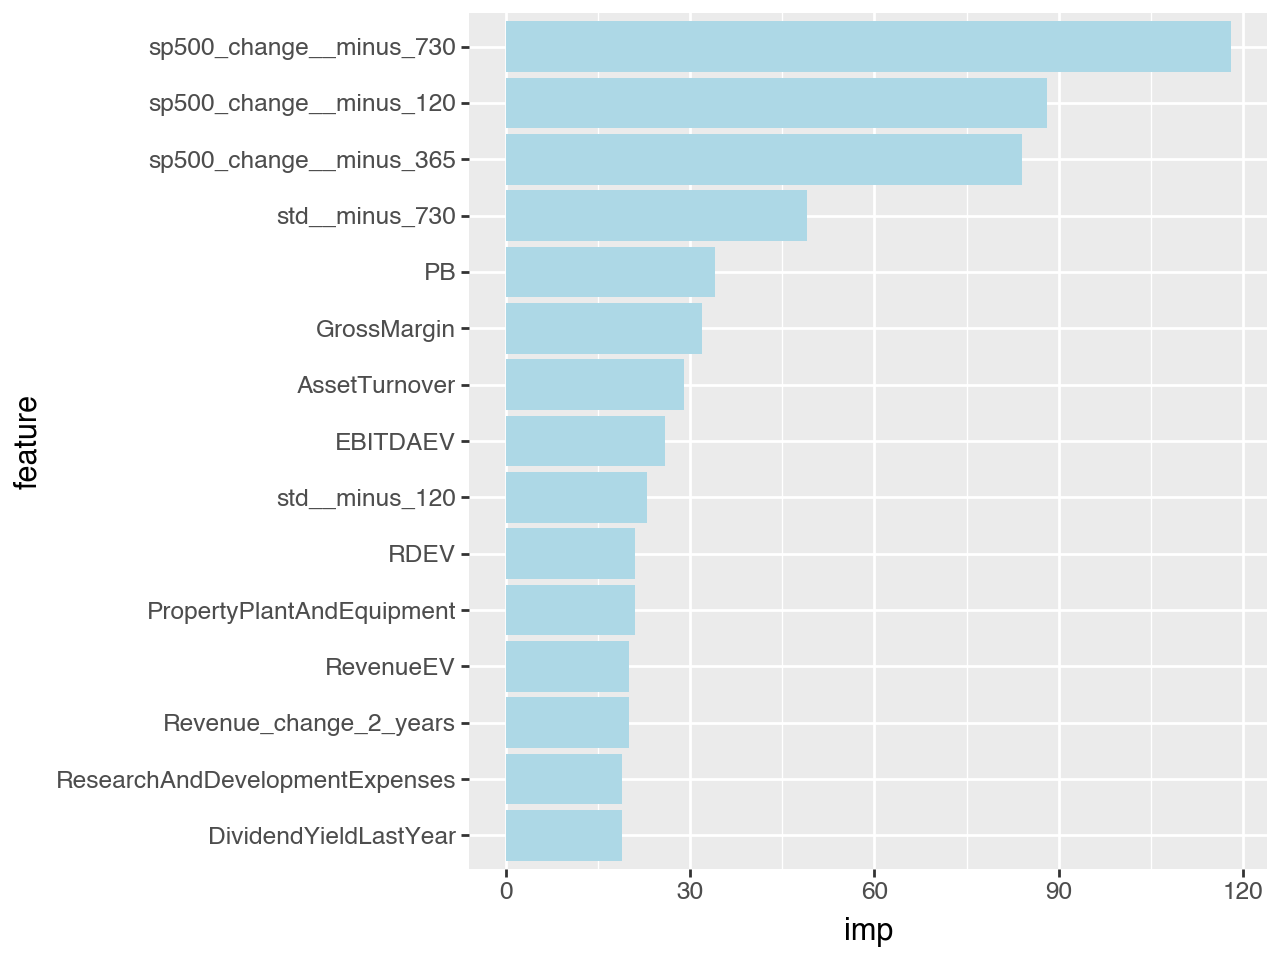

In [39]:
plot

Looking at feature importance, it looks like the SP500 performance is the one which drives more of the importance... Then, other related to the company features arise:
- `std_minus_720`: this could be an indicator of the momentum of the stock... 
- `PB`: price to book can also be an indicator. My gut feeling is that those companies with higher Price-to-Book have outperformed the SP500 (even though being more expensive, this value tends to be an indicator of the growth...).
- `RevenueEV`: Although the value investing says that high revenue/EV should mean undervalued... my gut feeling is that the model would encourage lower revenue/ev to drive the decisions (growth companies tend to have higher price growth over the past decades)

In [42]:
train_set.groupby("execution_date")[["sp500_change__minus_730", "sp500_change__minus_365","std__minus_730", "PB", "RevenueEV", "diff_ch_sp500"]]

In [43]:
# TODO: Check the relationship of sp500_change__minus_730, sp500_change__minus_365, and std__minus_730
# TODO: Try annonimize the features...

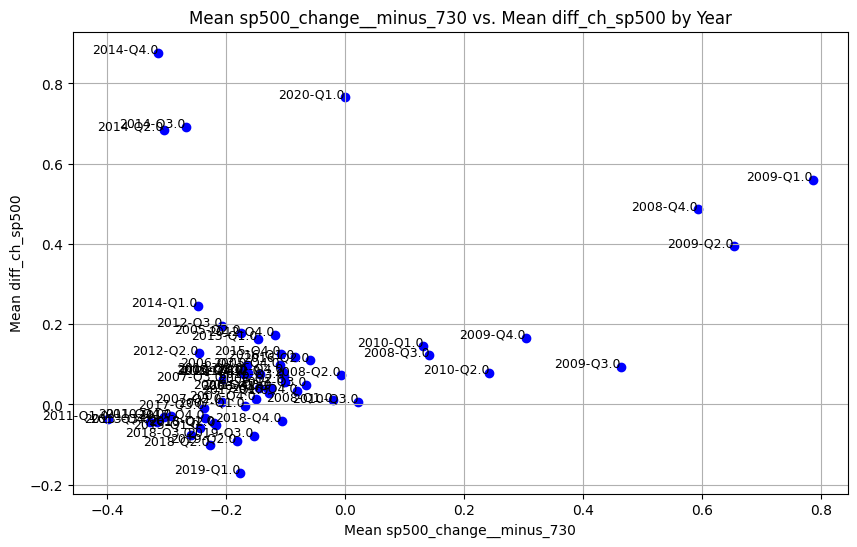

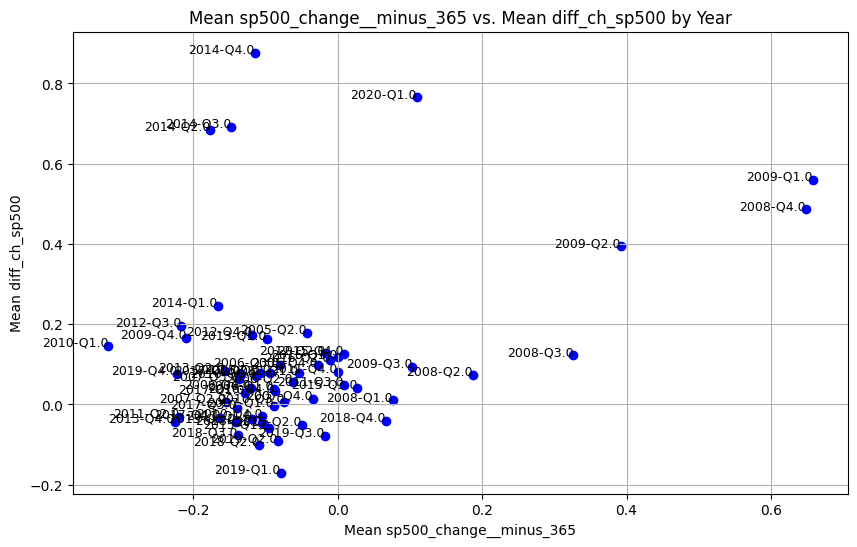

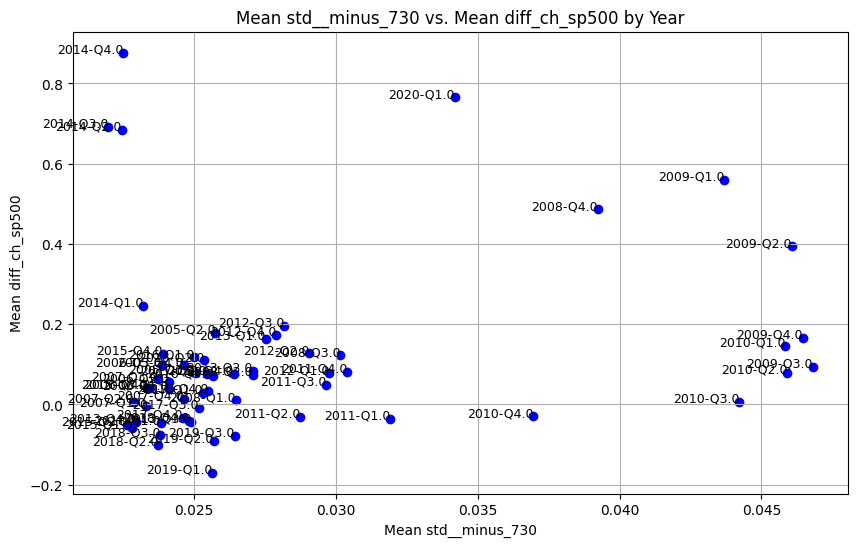

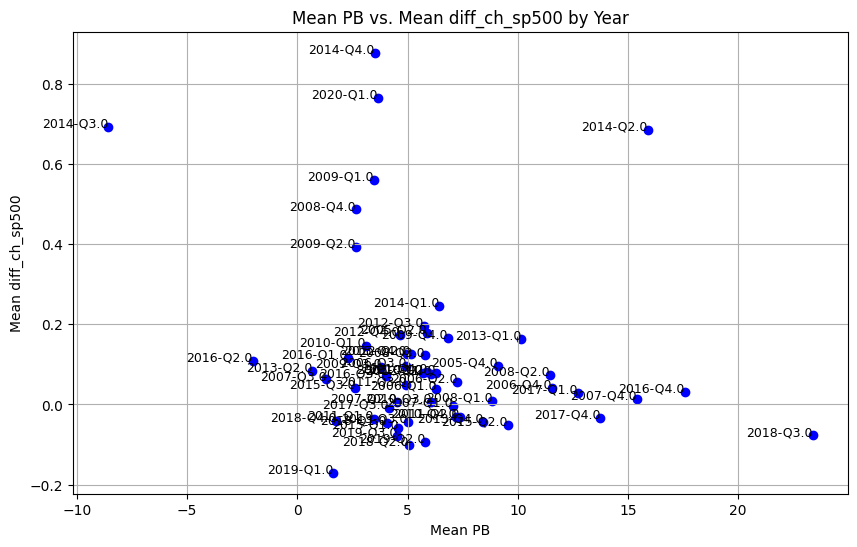

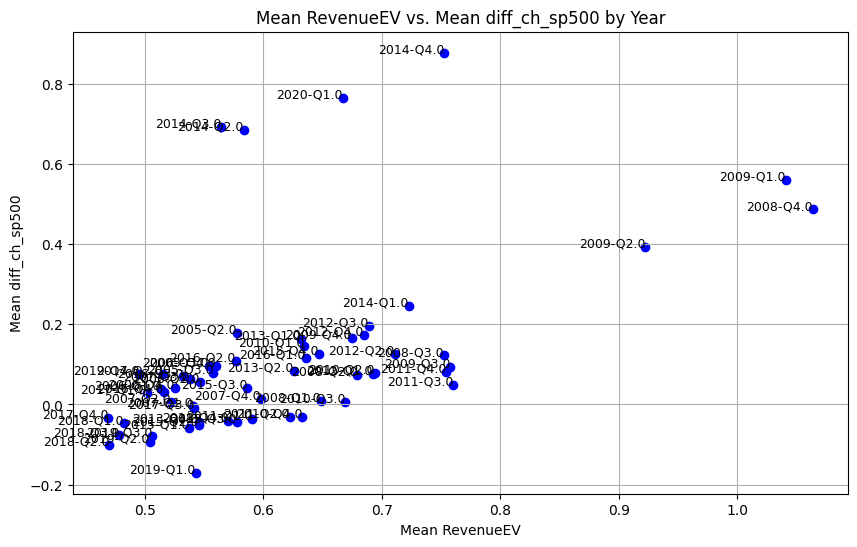

In [54]:
analysis_set = data_set[["execution_date", "sp500_change__minus_730", "sp500_change__minus_365","std__minus_730", "PB", "RevenueEV", "diff_ch_sp500"]]
analysis_set['year'] = analysis_set['execution_date'].dt.year
analysis_set['month'] = analysis_set['execution_date'].dt.month

# Group the data by year and compute the mean of each column
df_means = analysis_set.groupby(['year', 'month']).mean().reset_index()

# List of features to compare against diff_ch_sp500
features = ['sp500_change__minus_730', 'sp500_change__minus_365', 'std__minus_730', 'PB', 'RevenueEV']

# For each feature, create a scatter plot of the mean values
for feature in features:
    plt.figure(figsize=(10, 6))
    plt.scatter(df_means[feature], df_means['diff_ch_sp500'], color='b')
    
    # Annotate each point with the year for clarity
    for _, row in df_means.iterrows():
        plt.text(row[feature], row['diff_ch_sp500'], f"{int(row['year'])}-Q{int(row['month'])/3}", fontsize=9, ha='right')
    
    plt.title(f'Mean {feature} vs. Mean diff_ch_sp500 by Year')
    plt.xlabel(f'Mean {feature}')
    plt.ylabel('Mean diff_ch_sp500')
    plt.grid(True)
    plt.show()

In [60]:
analysis_set[["execution_date", "sp500_change__minus_730"]]

,execution_date,sp500_change__minus_730
0,2005-06-30,-0.175443
1,2005-06-30,-0.175443
2,2005-06-30,-0.175443
3,2005-06-30,-0.175443
4,2005-06-30,-0.175443
...,...,...
170478,2021-03-27,-0.291631
170479,2021-03-27,-0.291631
170480,2021-03-27,-0.291631
170481,2021-03-27,-0.291631


In [80]:
for col in data_set.columns:
    print(col)

Ticker
date
AssetTurnover
CashFlowFromFinancialActivities
CashFlowFromInvestingActivities
CashFlowFromOperatingActivities
CashOnHand
ChangeInAccountsPayable
ChangeInAccountsReceivable
ChangeInAssetsLiabilities
ChangeInInventories
CommonStockDividendsPaid
CommonStockNet
ComprehensiveIncome
CostOfGoodsSold
CurrentRatio
DaysSalesInReceivables
DebtIssuanceRetirementNet_minus_Total
DebtEquityRatio
EBIT
EBITMargin
EBITDA
EBITDAMargin
FinancialActivities_minus_Other
GoodwillAndIntangibleAssets
GrossMargin
GrossProfit
IncomeAfterTaxes
IncomeFromContinuousOperations
IncomeFromDiscontinuedOperations
IncomeTaxes
Inventory
InventoryTurnoverRatio
InvestingActivities_minus_Other
LongTermDebt
Long_minus_TermInvestments
Long_minus_termDebtCapital
NetAcquisitionsDivestitures
NetCashFlow
NetChangeInIntangibleAssets
NetChangeInInvestments_minus_Total
NetChangeInLong_minus_TermInvestments
NetChangeInPropertyPlantAndEquipment
NetChangeInShort_minus_termInvestments
NetCommonEquityIssuedRepurchased
NetCurren

After iterating within the `main.py` file...

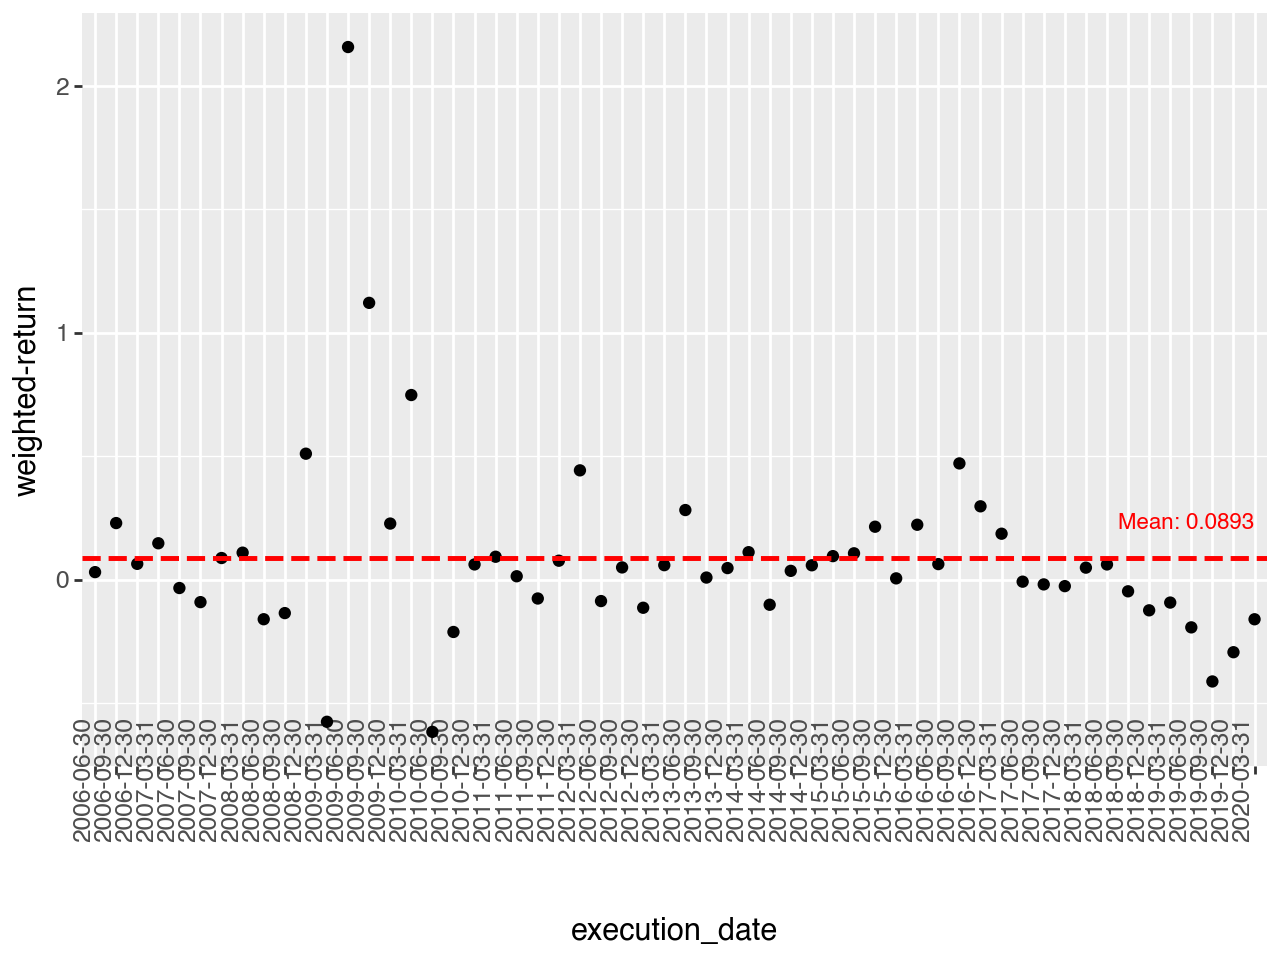